In [8]:
import sys
!{sys.executable} -m pip install -q wfdb scipy joblib

In [9]:
import os
import json
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import wfdb
import joblib

from scipy import signal
from scipy.signal import butter, filtfilt, welch, find_peaks

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
    auc
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python OK")
print("TensorFlow:", tf.__version__)

Python OK
TensorFlow: 2.20.0


In [10]:
# SỬA LẠI đường dẫn này theo máy của bạn
DATASET_DIR = r"C:\ml\kaggle-ml-basics\data\brno-university-of-technology-smartphone-ppg-database-but-ppg-2.0.0"

assert os.path.isdir(DATASET_DIR), f"Không tìm thấy DATASET_DIR: {DATASET_DIR}"

quality_path = os.path.join(DATASET_DIR, "quality-hr-ann.csv")
subject_info_path = os.path.join(DATASET_DIR, "subject-info.csv")

assert os.path.isfile(quality_path), f"Không tìm thấy file: {quality_path}"
assert os.path.isfile(subject_info_path), f"Không tìm thấy file: {subject_info_path}"

print("DATASET_DIR =", DATASET_DIR)
print("quality_path =", quality_path)
print("subject_info_path =", subject_info_path)

DATASET_DIR = C:\ml\kaggle-ml-basics\data\brno-university-of-technology-smartphone-ppg-database-but-ppg-2.0.0
quality_path = C:\ml\kaggle-ml-basics\data\brno-university-of-technology-smartphone-ppg-database-but-ppg-2.0.0\quality-hr-ann.csv
subject_info_path = C:\ml\kaggle-ml-basics\data\brno-university-of-technology-smartphone-ppg-database-but-ppg-2.0.0\subject-info.csv


In [11]:
quality_df = pd.read_csv(quality_path)
subject_df = pd.read_csv(subject_info_path)

quality_df["ID"] = quality_df["ID"].astype(str).str.zfill(6)
subject_df["ID"] = subject_df["ID"].astype(str).str.zfill(6)

quality_df["subject_id"] = quality_df["ID"].str[:3]
subject_df["subject_id"] = subject_df["ID"].str[:3]

df = quality_df.merge(subject_df, on=["ID", "subject_id"], how="left")

print("quality_df shape:", quality_df.shape)
print("subject_df shape:", subject_df.shape)
print("merged df shape:", df.shape)
print("Số record:", len(df))
print("Số subject:", df["subject_id"].nunique())

display(df.head())
print("\nPhân bố nhãn Quality:")
print(df["Quality"].value_counts(dropna=False))

quality_df shape: (3888, 4)
subject_df shape: (3888, 11)
merged df shape: (3888, 13)
Số record: 3888
Số subject: 50


,ID,Quality,HR,subject_id,Gender,Age [years],Height [cm],Weight [kg],Ear/finger,Motion,Blood pressure [mmHg],Glycaemia [mmol/l],SpO2 [%]
0,100001,1,83,100,F,51,NaN,58,1,0,NaN,NaN,NaN
1,100002,1,85,100,F,51,NaN,58,1,0,NaN,NaN,NaN
2,100003,1,81,100,F,51,NaN,58,1,0,NaN,NaN,NaN
3,100004,0,85,100,F,51,NaN,58,1,2;3,NaN,NaN,NaN
4,101001,1,67,101,F,54,NaN,63,1,0,NaN,NaN,NaN



Phân bố nhãn Quality:
Quality
0    3058
1     830
Name: count, dtype: int64


In [12]:
def get_ppg_record_path(record_id: str):
    """
    WFDB path không kèm đuôi.
    Ví dụ:
      .../100001/100001_PPG
    """
    record_dir = os.path.join(DATASET_DIR, record_id)
    base = os.path.join(record_dir, f"{record_id}_PPG")
    hea = base + ".hea"
    dat = base + ".dat"
    if os.path.isfile(hea) and os.path.isfile(dat):
        return base
    return None


def get_ppg_1d_signal(record):
    """
    Chuẩn hóa output wfdb.rdrecord về vector 1D.
    """
    p = np.asarray(record.p_signal, dtype=np.float32)

    if p.ndim == 1:
        return p

    if p.shape[0] >= p.shape[1]:
        return p[:, 0].astype(np.float32)

    return p[0, :].astype(np.float32)


def load_record_ppg(record_id: str):
    path = get_ppg_record_path(record_id)
    if path is None:
        raise FileNotFoundError(f"Không tìm thấy record: {record_id}")

    rec = wfdb.rdrecord(path)
    sig = get_ppg_1d_signal(rec)
    fs = float(rec.fs)

    return sig, fs

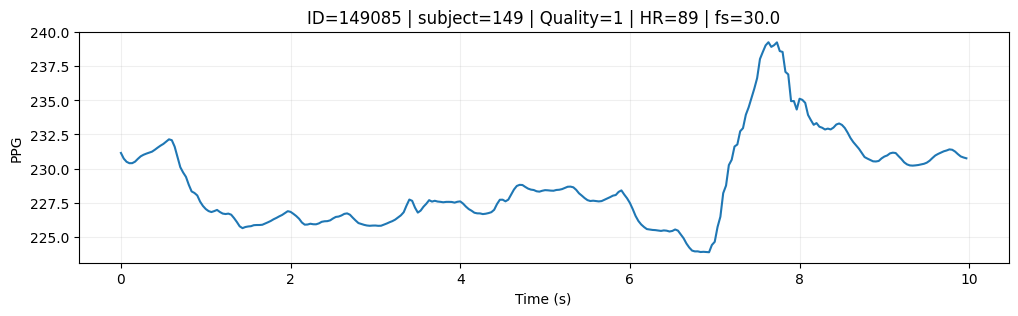

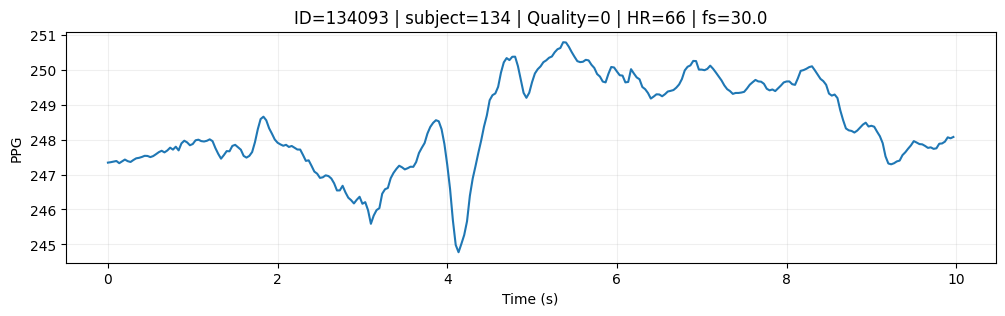

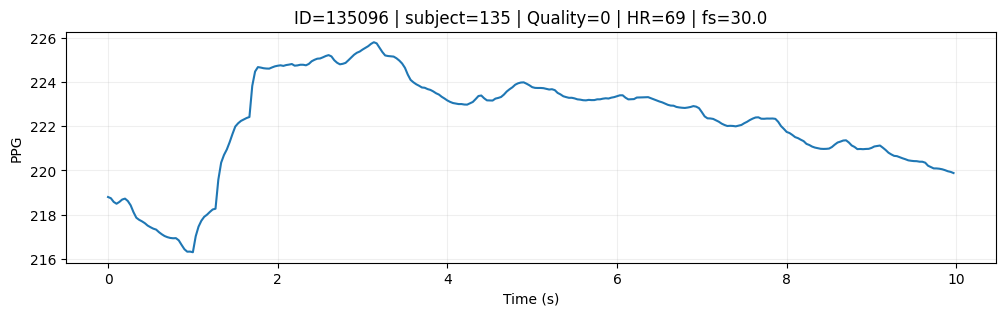

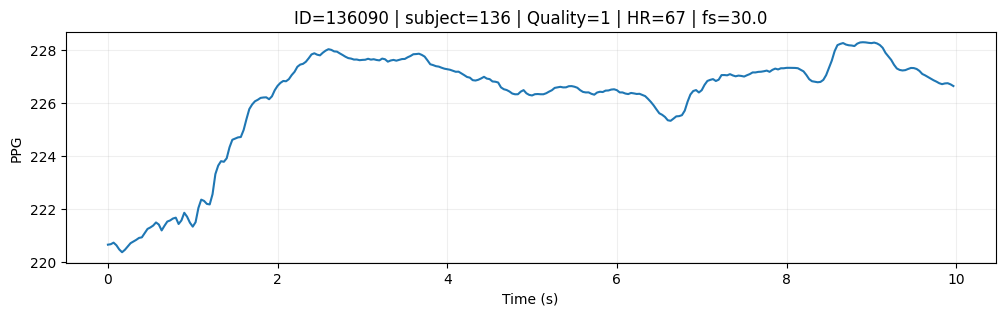

In [13]:
sample_ids = df["ID"].sample(4, random_state=SEED).tolist()

for rid in sample_ids:
    sig, fs = load_record_ppg(rid)
    row = df[df["ID"] == rid].iloc[0]

    t = np.arange(len(sig)) / fs

    plt.figure(figsize=(12, 3))
    plt.plot(t, sig)
    plt.title(f"ID={rid} | subject={row['subject_id']} | Quality={row['Quality']} | HR={row.get('HR', np.nan)} | fs={fs}")
    plt.xlabel("Time (s)")
    plt.ylabel("PPG")
    plt.grid(alpha=0.2)
    plt.show()

In [14]:
def safe_nan_to_num(x):
    x = np.asarray(x, dtype=np.float32)
    return np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)


def detrend_signal(x):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < 3:
        return x.copy()
    return signal.detrend(x).astype(np.float32)


def butter_bandpass_filter(x, fs, lowcut=0.7, highcut=5.0, order=3):
    x = np.asarray(x, dtype=np.float32)

    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq

    if high >= 1.0:
        high = 0.99
    if low <= 0.0:
        low = 0.001
    if low >= high:
        return x.copy()

    b, a = butter(order, [low, high], btype="band")
    if len(x) < max(len(a), len(b)) * 3:
        return x.copy()

    y = filtfilt(b, a, x)
    return y.astype(np.float32)


def robust_zscore(x):
    x = np.asarray(x, dtype=np.float32)
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    scale = 1.4826 * mad
    if scale < 1e-8:
        scale = np.std(x)
    if scale < 1e-8:
        scale = 1.0
    z = (x - med) / scale
    return z.astype(np.float32)


def preprocess_ppg(sig, fs):
    """
    Pipeline chuẩn cho feature extraction:
    1) nan_to_num
    2) detrend
    3) bandpass 0.7-5.0 Hz
    4) robust z-score
    """
    x_raw = safe_nan_to_num(sig)
    x_dt = detrend_signal(x_raw)
    x_bp = butter_bandpass_filter(x_dt, fs=fs, lowcut=0.7, highcut=5.0, order=3)
    x_norm = robust_zscore(x_bp)
    return x_raw, x_dt, x_bp, x_norm

In [15]:
def normalized_autocorr(x):
    x = np.asarray(x, dtype=np.float32)
    x = x - np.mean(x)
    denom = np.sum(x * x)
    if denom < 1e-8:
        return np.zeros(len(x), dtype=np.float32)

    ac = np.correlate(x, x, mode="full")
    ac = ac[len(x)-1:] / denom
    return ac.astype(np.float32)


def spectral_entropy_from_psd(psd):
    psd = np.asarray(psd, dtype=np.float64)
    psd = np.maximum(psd, 1e-12)
    psd = psd / np.sum(psd)
    return float(-np.sum(psd * np.log(psd)) / np.log(len(psd)))


def bandpower(freqs, psd, fmin, fmax):
    mask = (freqs >= fmin) & (freqs <= fmax)
    if np.sum(mask) == 0:
        return 0.0
    return float(np.trapz(psd[mask], freqs[mask]))


def extract_ppg_features(sig_raw, fs):
    """
    Chỉ dùng feature suy ra từ PPG.
    Không dùng metadata.
    """
    x_raw, x_dt, x_bp, x = preprocess_ppg(sig_raw, fs)
    n = len(x)

    feats = {}
    feats["n_samples"] = float(n)
    feats["fs"] = float(fs)
    feats["duration_sec"] = float(n / fs)

    # =========================
    # Time-domain cơ bản
    # =========================
    dx = np.diff(x)
    ddx = np.diff(dx)

    feats["mean"] = float(np.mean(x))
    feats["std"] = float(np.std(x))
    feats["median"] = float(np.median(x))
    feats["min"] = float(np.min(x))
    feats["max"] = float(np.max(x))
    feats["ptp"] = float(np.ptp(x))
    feats["q10"] = float(np.percentile(x, 10))
    feats["q25"] = float(np.percentile(x, 25))
    feats["q75"] = float(np.percentile(x, 75))
    feats["q90"] = float(np.percentile(x, 90))
    feats["iqr"] = float(np.percentile(x, 75) - np.percentile(x, 25))
    feats["rms"] = float(np.sqrt(np.mean(x**2)))
    feats["energy"] = float(np.mean(x**2))
    feats["abs_mean"] = float(np.mean(np.abs(x)))
    feats["mad_mean"] = float(np.mean(np.abs(x - np.mean(x))))

    feats["dx_std"] = float(np.std(dx)) if len(dx) > 0 else 0.0
    feats["ddx_std"] = float(np.std(ddx)) if len(ddx) > 0 else 0.0
    feats["slope_abs_mean"] = float(np.mean(np.abs(dx))) if len(dx) > 0 else 0.0

    # Skew / kurtosis gần đúng
    s = np.std(x)
    if s < 1e-8:
        feats["skew"] = 0.0
        feats["kurtosis"] = 0.0
    else:
        xc = (x - np.mean(x)) / s
        feats["skew"] = float(np.mean(xc**3))
        feats["kurtosis"] = float(np.mean(xc**4))

    # =========================
    # Peak features
    # =========================
    # khoảng cách peak tối thiểu tương ứng ~180 bpm
    min_distance = max(1, int(fs * 0.33))
    prominence = max(0.05, 0.15 * np.std(x))

    peaks, peak_props = find_peaks(
        x,
        distance=min_distance,
        prominence=prominence
    )

    feats["n_peaks"] = float(len(peaks))
    feats["peak_rate_per_sec"] = float(len(peaks) / (n / fs)) if n > 0 else 0.0

    if len(peaks) >= 2:
        ibi = np.diff(peaks) / fs
        hr_inst = 60.0 / np.clip(ibi, 1e-6, None)

        feats["ibi_mean"] = float(np.mean(ibi))
        feats["ibi_std"] = float(np.std(ibi))
        feats["ibi_min"] = float(np.min(ibi))
        feats["ibi_max"] = float(np.max(ibi))

        feats["hr_est_mean"] = float(np.mean(hr_inst))
        feats["hr_est_std"] = float(np.std(hr_inst))

        diffs = np.diff(ibi)
        feats["ibi_diff_rmssd"] = float(np.sqrt(np.mean(diffs**2))) if len(diffs) > 0 else 0.0
    else:
        feats["ibi_mean"] = 0.0
        feats["ibi_std"] = 0.0
        feats["ibi_min"] = 0.0
        feats["ibi_max"] = 0.0
        feats["hr_est_mean"] = 0.0
        feats["hr_est_std"] = 0.0
        feats["ibi_diff_rmssd"] = 0.0

    if len(peaks) > 0 and "prominences" in peak_props:
        prom = peak_props["prominences"]
        feats["peak_prom_mean"] = float(np.mean(prom))
        feats["peak_prom_std"] = float(np.std(prom))
    else:
        feats["peak_prom_mean"] = 0.0
        feats["peak_prom_std"] = 0.0

    # =========================
    # Autocorrelation features
    # =========================
    ac = normalized_autocorr(x)

    lag_min = int(fs * 60 / 180)   # 180 bpm
    lag_max = int(fs * 60 / 40)    # 40 bpm
    lag_max = min(lag_max, len(ac) - 1)

    if lag_max > lag_min:
        ac_band = ac[lag_min:lag_max + 1]
        best_idx = np.argmax(ac_band)
        best_lag = lag_min + best_idx
        best_ac = ac[best_lag]

        feats["ac_best"] = float(best_ac)
        feats["ac_best_lag_sec"] = float(best_lag / fs)
        feats["ac_best_hr"] = float(60.0 / (best_lag / fs))
    else:
        feats["ac_best"] = 0.0
        feats["ac_best_lag_sec"] = 0.0
        feats["ac_best_hr"] = 0.0

    feats["ac_lag1"] = float(ac[1]) if len(ac) > 1 else 0.0
    feats["ac_lag2"] = float(ac[2]) if len(ac) > 2 else 0.0

    # =========================
    # Frequency-domain features
    # =========================
    nperseg = min(256, len(x))
    if nperseg >= 32:
        freqs, psd = welch(x, fs=fs, nperseg=nperseg)
        psd = np.maximum(psd, 1e-12)

        total_power = bandpower(freqs, psd, 0.0, min(8.0, fs / 2))
        hr_power = bandpower(freqs, psd, 0.7, 3.5)
        low_power = bandpower(freqs, psd, 0.0, 0.7)
        high_power = bandpower(freqs, psd, 3.5, min(8.0, fs / 2))

        feats["psd_total_power"] = float(total_power)
        feats["psd_hr_power"] = float(hr_power)
        feats["psd_low_power"] = float(low_power)
        feats["psd_high_power"] = float(high_power)
        feats["psd_hr_ratio"] = float(hr_power / (total_power + 1e-8))
        feats["psd_low_ratio"] = float(low_power / (total_power + 1e-8))
        feats["psd_high_ratio"] = float(high_power / (total_power + 1e-8))
        feats["spectral_entropy"] = spectral_entropy_from_psd(psd)

        hr_mask = (freqs >= 0.7) & (freqs <= 3.5)
        if np.sum(hr_mask) > 0:
            f_hr = freqs[hr_mask]
            p_hr = psd[hr_mask]
            idx = np.argmax(p_hr)
            dom_freq = f_hr[idx]
            dom_power = p_hr[idx]
            feats["dom_freq_hr_band"] = float(dom_freq)
            feats["dom_bpm_hr_band"] = float(dom_freq * 60.0)
            feats["dom_power_hr_band"] = float(dom_power)
        else:
            feats["dom_freq_hr_band"] = 0.0
            feats["dom_bpm_hr_band"] = 0.0
            feats["dom_power_hr_band"] = 0.0
    else:
        feats["psd_total_power"] = 0.0
        feats["psd_hr_power"] = 0.0
        feats["psd_low_power"] = 0.0
        feats["psd_high_power"] = 0.0
        feats["psd_hr_ratio"] = 0.0
        feats["psd_low_ratio"] = 0.0
        feats["psd_high_ratio"] = 0.0
        feats["spectral_entropy"] = 0.0
        feats["dom_freq_hr_band"] = 0.0
        feats["dom_bpm_hr_band"] = 0.0
        feats["dom_power_hr_band"] = 0.0

    # =========================
    # Shape / clipping proxy
    # =========================
    feats["raw_std"] = float(np.std(x_raw))
    feats["raw_ptp"] = float(np.ptp(x_raw))

    raw_min = np.min(x_raw)
    raw_max = np.max(x_raw)
    span = raw_max - raw_min + 1e-8

    low_clip_thr = raw_min + 0.01 * span
    high_clip_thr = raw_max - 0.01 * span

    feats["clip_low_ratio"] = float(np.mean(x_raw <= low_clip_thr))
    feats["clip_high_ratio"] = float(np.mean(x_raw >= high_clip_thr))

    # =========================
    # Heuristic consistency
    # =========================
    hr_peak = feats["hr_est_mean"]
    hr_ac = feats["ac_best_hr"]
    hr_fft = feats["dom_bpm_hr_band"]

    if hr_peak > 0 and hr_ac > 0:
        feats["hr_peak_ac_diff"] = float(abs(hr_peak - hr_ac))
    else:
        feats["hr_peak_ac_diff"] = 0.0

    if hr_peak > 0 and hr_fft > 0:
        feats["hr_peak_fft_diff"] = float(abs(hr_peak - hr_fft))
    else:
        feats["hr_peak_fft_diff"] = 0.0

    if hr_ac > 0 and hr_fft > 0:
        feats["hr_ac_fft_diff"] = float(abs(hr_ac - hr_fft))
    else:
        feats["hr_ac_fft_diff"] = 0.0

    # sanitize
    for k, v in feats.items():
        if isinstance(v, (float, np.floating)):
            if np.isnan(v) or np.isinf(v):
                feats[k] = 0.0

    return feats

test_id: 100001
fs: 30.0
len(sig): 300
Số features: 57
Một vài features đầu:
n_samples: 300.0
fs: 30.0
duration_sec: 10.0
mean: 0.06753091514110565
std: 1.0824812650680542
median: 0.0
min: -2.9014177322387695
max: 3.067932605743408
ptp: 5.969350337982178
q10: -1.2343120574951172


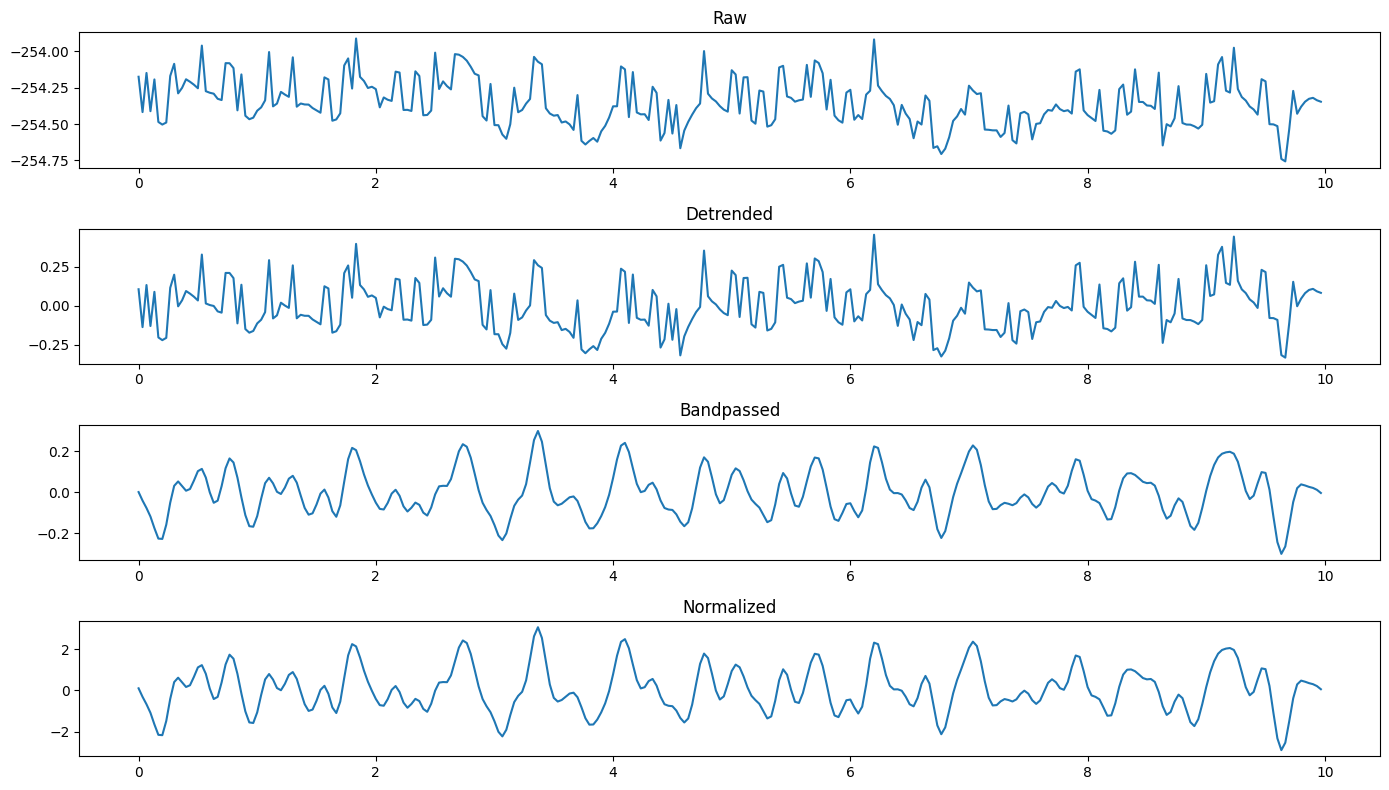

In [16]:
# Numpy 2.x có thể không còn np.trapz, nên vá lại hàm bandpower để dùng np.trapezoid an toàn
def bandpower(freqs, psd, fmin, fmax):
    mask = (freqs >= fmin) & (freqs <= fmax)
    if np.sum(mask) == 0:
        return 0.0
    integrator = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
    return float(integrator(psd[mask], freqs[mask]))

test_id = df.iloc[0]["ID"]
sig, fs = load_record_ppg(test_id)
x_raw, x_dt, x_bp, x_norm = preprocess_ppg(sig, fs)
feats = extract_ppg_features(sig, fs)

print("test_id:", test_id)
print("fs:", fs)
print("len(sig):", len(sig))
print("Số features:", len(feats))
print("Một vài features đầu:")
for i, (k, v) in enumerate(feats.items()):
    print(f"{k}: {v}")
    if i >= 9:
        break

t = np.arange(len(sig)) / fs

plt.figure(figsize=(14, 8))

plt.subplot(4, 1, 1)
plt.plot(t, x_raw)
plt.title("Raw")

plt.subplot(4, 1, 2)
plt.plot(t, x_dt)
plt.title("Detrended")

plt.subplot(4, 1, 3)
plt.plot(t, x_bp)
plt.title("Bandpassed")

plt.subplot(4, 1, 4)
plt.plot(t, x_norm)
plt.title("Normalized")

plt.tight_layout()
plt.show()

In [17]:
rows = []
errors = []

for idx, row in df.iterrows():
    rid = row["ID"]

    try:
        sig, fs = load_record_ppg(rid)
        feats = extract_ppg_features(sig, fs)

        item = {
            "ID": rid,
            "subject_id": str(row["subject_id"]),
            "Quality": int(row["Quality"]),
        }

        # chỉ giữ HR tham chiếu để phân tích, KHÔNG dùng train
        if "HR" in row.index and pd.notna(row["HR"]):
            item["HR_ref"] = float(row["HR"])
        else:
            item["HR_ref"] = np.nan

        item.update(feats)
        rows.append(item)

    except Exception as e:
        errors.append((rid, str(e)))

feature_df = pd.DataFrame(rows)

print("feature_df shape:", feature_df.shape)
print("Số lỗi đọc record:", len(errors))
if len(errors) > 0:
    print("Ví dụ lỗi đầu tiên:", errors[0])

display(feature_df.head())

feature_df shape: (3888, 61)
Số lỗi đọc record: 0


,ID,subject_id,Quality,HR_ref,n_samples,fs,duration_sec,mean,std,median,...,dom_freq_hr_band,dom_bpm_hr_band,dom_power_hr_band,raw_std,raw_ptp,clip_low_ratio,clip_high_ratio,hr_peak_ac_diff,hr_peak_fft_diff,hr_ac_fft_diff
0,100001,100,1,83.0,300.0,30.0,10.0,0.067531,1.082481,0.000000e+00,...,1.406250,84.3750,3.133056,0.163361,0.845718,0.003333,0.006667,46.096657,43.539839,2.556818
1,100002,100,1,85.0,300.0,30.0,10.0,0.183814,0.897153,0.000000e+00,...,1.406250,84.3750,2.707918,0.220934,1.128220,0.010000,0.003333,22.919202,20.362384,2.556818
2,100003,100,1,81.0,300.0,30.0,10.0,0.022625,0.930992,4.220055e-10,...,1.406250,84.3750,2.965488,0.324770,1.680481,0.003333,0.003333,35.976685,33.419867,2.556818
3,100004,100,0,85.0,300.0,30.0,10.0,-0.012089,1.096503,0.000000e+00,...,1.171875,70.3125,2.509276,29.052874,163.552200,0.123333,0.003333,65.935355,73.883725,7.948370
4,101001,101,1,67.0,300.0,30.0,10.0,0.109303,0.869111,5.355105e-09,...,1.171875,70.3125,3.068834,0.157399,0.615112,0.010000,0.006667,1.348422,2.297412,3.645833


In [18]:
print("Số record sau xử lý:", len(feature_df))
print("Số subject:", feature_df["subject_id"].nunique())
print("\nPhân bố Quality:")
print(feature_df["Quality"].value_counts(dropna=False))

nan_counts = feature_df.isna().sum().sort_values(ascending=False)
print("\nTop cột có NaN:")
display(nan_counts.head(10))

num_cols = feature_df.select_dtypes(include=[np.number]).columns.tolist()
display(feature_df[num_cols].describe().T.head(20))

Số record sau xử lý: 3888
Số subject: 50

Phân bố Quality:
Quality
0    3058
1     830
Name: count, dtype: int64

Top cột có NaN:


ID              0
subject_id      0
Quality         0
HR_ref          0
n_samples       0
fs              0
duration_sec    0
mean            0
std             0
median          0
dtype: int64

,count,mean,std,min,25%,50%,75%,max
Quality,3888.0,2.134774e-01,4.098146e-01,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,1.000000e+00
HR_ref,3888.0,7.814660e+01,1.332982e+01,3.800000e+01,6.900000e+01,77.000000,8.500000e+01,1.610000e+02
n_samples,3888.0,3.000000e+02,0.000000e+00,3.000000e+02,3.000000e+02,300.000000,3.000000e+02,3.000000e+02
fs,3888.0,3.000000e+01,0.000000e+00,3.000000e+01,3.000000e+01,30.000000,3.000000e+01,3.000000e+01
duration_sec,3888.0,1.000000e+01,0.000000e+00,1.000000e+01,1.000000e+01,10.000000,1.000000e+01,1.000000e+01
mean,3888.0,5.655156e-02,2.587552e+00,-4.386912e+01,-3.747883e-02,0.017421,7.839527e-02,1.089666e+02
std,3888.0,4.330864e+00,3.904920e+01,7.454360e-01,1.047772e+00,1.288429,1.920933e+00,1.617771e+03
median,3888.0,7.021493e-12,3.042433e-09,-3.422610e-08,-2.328306e-10,0.000000,2.337401e-10,2.561137e-08
min,3888.0,-1.983488e+01,1.941968e+02,-7.499747e+03,-7.500620e+00,-4.171759,-2.746176e+00,-9.557738e-01
max,3888.0,1.999632e+01,2.242552e+02,1.272941e+00,2.845825e+00,4.098089,7.374069e+00,9.499916e+03


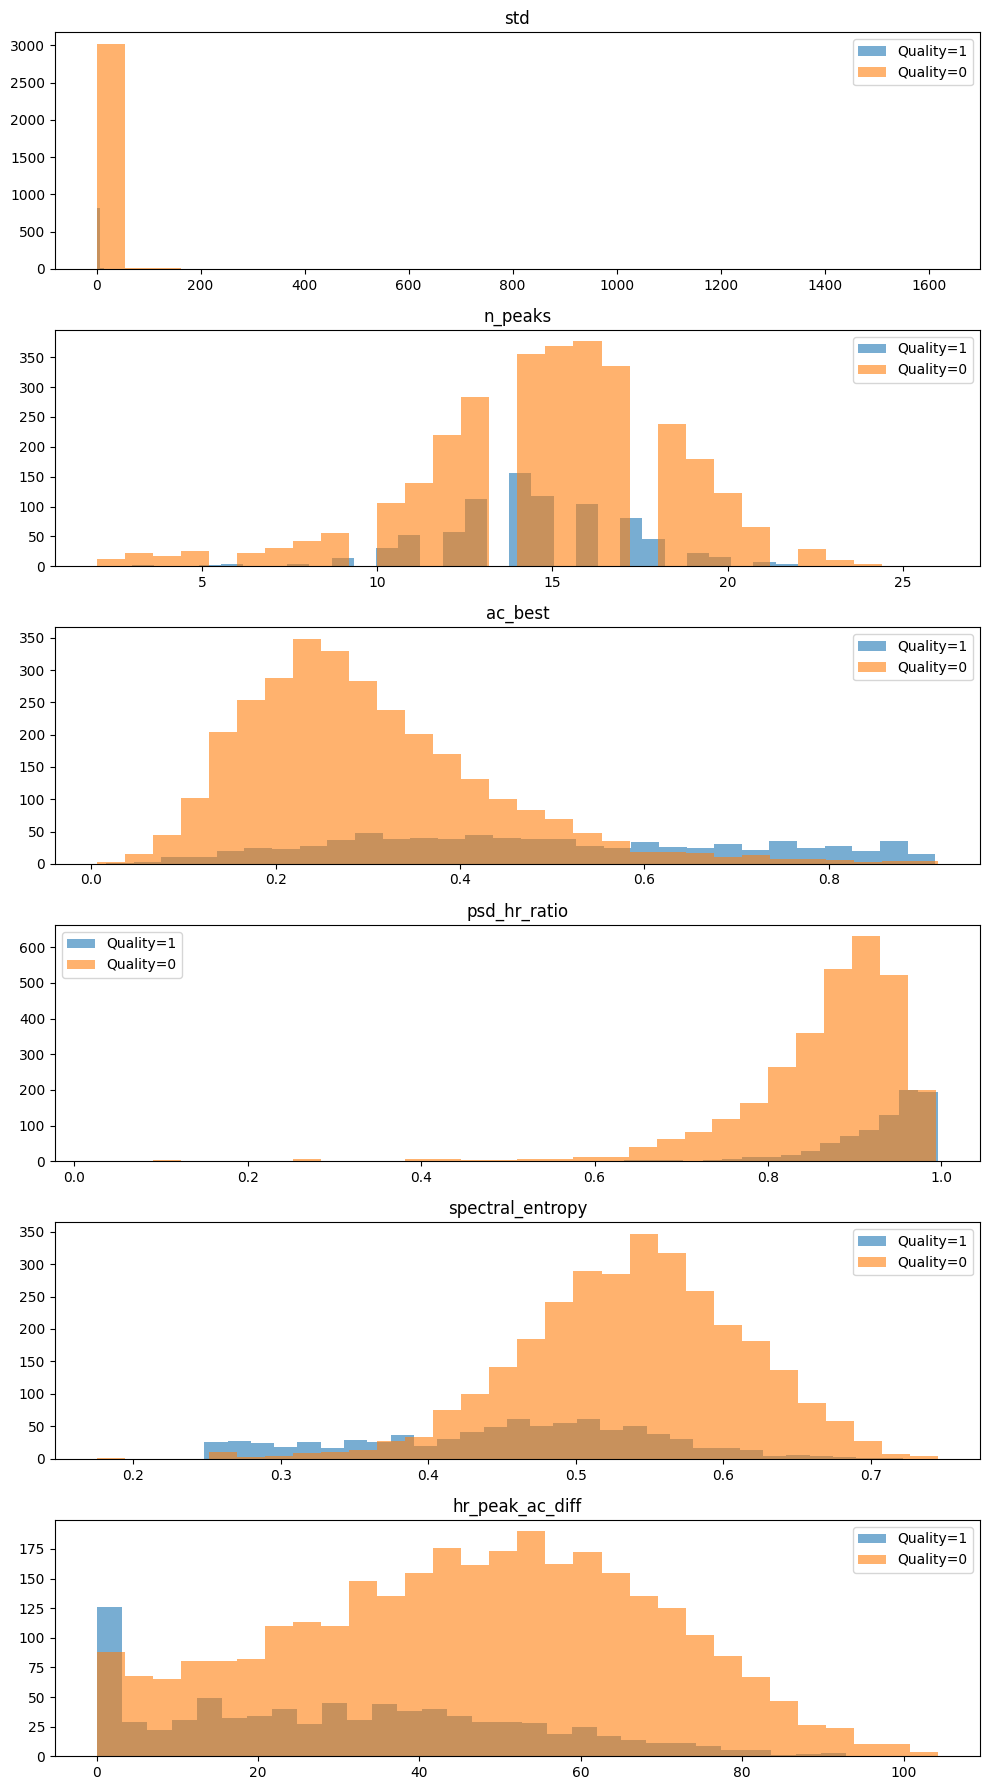

In [19]:
plot_cols = [
    "std",
    "n_peaks",
    "ac_best",
    "psd_hr_ratio",
    "spectral_entropy",
    "hr_peak_ac_diff"
]

fig, axes = plt.subplots(len(plot_cols), 1, figsize=(10, 3 * len(plot_cols)))

for ax, col in zip(axes, plot_cols):
    good = feature_df.loc[feature_df["Quality"] == 1, col].dropna()
    bad = feature_df.loc[feature_df["Quality"] == 0, col].dropna()

    ax.hist(good, bins=30, alpha=0.6, label="Quality=1")
    ax.hist(bad, bins=30, alpha=0.6, label="Quality=0")
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

In [20]:
groups = feature_df["subject_id"].values
y_all = feature_df["Quality"].values.astype(np.int64)

# Bước 1: tách test 20% theo subject
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
trainval_idx, test_idx = next(gss1.split(feature_df, y_all, groups=groups))

trainval_df = feature_df.iloc[trainval_idx].reset_index(drop=True)
test_df = feature_df.iloc[test_idx].reset_index(drop=True)

# Bước 2: từ trainval tách val 20% theo subject
groups_tv = trainval_df["subject_id"].values
y_tv = trainval_df["Quality"].values.astype(np.int64)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED + 1)
train_idx, val_idx = next(gss2.split(trainval_df, y_tv, groups=groups_tv))

train_df = trainval_df.iloc[train_idx].reset_index(drop=True)
val_df = trainval_df.iloc[val_idx].reset_index(drop=True)

print("Train:", len(train_df), "records | subjects:", train_df["subject_id"].nunique())
print("Val  :", len(val_df), "records | subjects:", val_df["subject_id"].nunique())
print("Test :", len(test_df), "records | subjects:", test_df["subject_id"].nunique())

train_subjects = set(train_df["subject_id"])
val_subjects = set(val_df["subject_id"])
test_subjects = set(test_df["subject_id"])

print("\nOverlap train/val :", len(train_subjects.intersection(val_subjects)))
print("Overlap train/test:", len(train_subjects.intersection(test_subjects)))
print("Overlap val/test  :", len(val_subjects.intersection(test_subjects)))

print("\nTrain label ratio:")
print(train_df["Quality"].value_counts(normalize=True))
print("\nVal label ratio:")
print(val_df["Quality"].value_counts(normalize=True))
print("\nTest label ratio:")
print(test_df["Quality"].value_counts(normalize=True))

Train: 2400 records | subjects: 32
Val  : 498 records | subjects: 8
Test : 990 records | subjects: 10

Overlap train/val : 0
Overlap train/test: 0
Overlap val/test  : 0

Train label ratio:
Quality
0    0.754167
1    0.245833
Name: proportion, dtype: float64

Val label ratio:
Quality
0    0.839357
1    0.160643
Name: proportion, dtype: float64

Test label ratio:
Quality
0    0.838384
1    0.161616
Name: proportion, dtype: float64


In [21]:
# Chỉ dùng feature từ PPG, không dùng:
# - ID
# - subject_id
# - Quality (label)
# - HR_ref (reference)
exclude_cols = [
    "ID", "subject_id", "Quality", "HR_ref",
    "n_samples", "fs", "duration_sec"
]

feature_cols = [c for c in feature_df.columns if c not in exclude_cols]

print("Số feature dùng train:", len(feature_cols))
print(feature_cols)

Số feature dùng train: 54
['mean', 'std', 'median', 'min', 'max', 'ptp', 'q10', 'q25', 'q75', 'q90', 'iqr', 'rms', 'energy', 'abs_mean', 'mad_mean', 'dx_std', 'ddx_std', 'slope_abs_mean', 'skew', 'kurtosis', 'n_peaks', 'peak_rate_per_sec', 'ibi_mean', 'ibi_std', 'ibi_min', 'ibi_max', 'hr_est_mean', 'hr_est_std', 'ibi_diff_rmssd', 'peak_prom_mean', 'peak_prom_std', 'ac_best', 'ac_best_lag_sec', 'ac_best_hr', 'ac_lag1', 'ac_lag2', 'psd_total_power', 'psd_hr_power', 'psd_low_power', 'psd_high_power', 'psd_hr_ratio', 'psd_low_ratio', 'psd_high_ratio', 'spectral_entropy', 'dom_freq_hr_band', 'dom_bpm_hr_band', 'dom_power_hr_band', 'raw_std', 'raw_ptp', 'clip_low_ratio', 'clip_high_ratio', 'hr_peak_ac_diff', 'hr_peak_fft_diff', 'hr_ac_fft_diff']


In [22]:
X_train = train_df[feature_cols].copy().astype(np.float32).values
y_train = train_df["Quality"].values.astype(np.int64)

X_val = val_df[feature_cols].copy().astype(np.float32).values
y_val = val_df["Quality"].values.astype(np.int64)

X_test = test_df[feature_cols].copy().astype(np.float32).values
y_test = test_df["Quality"].values.astype(np.int64)

# xử lý NaN/inf lần cuối
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_val = np.nan_to_num(X_val, nan=0.0, posinf=0.0, neginf=0.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_val_sc = scaler.transform(X_val).astype(np.float32)
X_test_sc = scaler.transform(X_test).astype(np.float32)

print("X_train_sc:", X_train_sc.shape)
print("X_val_sc  :", X_val_sc.shape)
print("X_test_sc :", X_test_sc.shape)

X_train_sc: (2400, 54)
X_val_sc  : (498, 54)
X_test_sc : (990, 54)


In [23]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(cls): float(w) for cls, w in zip(classes, weights)}
print("Class weight:", class_weight_dict)

Class weight: {0: 0.6629834254143646, 1: 2.0338983050847457}


In [24]:
def build_tiny_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.20),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.10),
        layers.Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="acc"),
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ]
    )
    return model

model = build_tiny_mlp(X_train_sc.shape[1])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

history = model.fit(
    X_train_sc,
    y_train,
    validation_data=(X_val_sc, y_val),
    epochs=120,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/120
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.6854 - auc: 0.7466 - loss: 0.6078 - precision: 0.4136 - recall: 0.6695 - val_acc: 0.8153 - val_auc: 0.8546 - val_loss: 0.4719 - val_precision: 0.4531 - val_recall: 0.7250 - learning_rate: 0.0010
Epoch 2/120
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7671 - auc: 0.8188 - loss: 0.5363 - precision: 0.5182 - recall: 0.7492 - val_acc: 0.8434 - val_auc: 0.8666 - val_loss: 0.4157 - val_precision: 0.5083 - val_recall: 0.7625 - learning_rate: 0.0010
Epoch 3/120
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7825 - auc: 0.8429 - loss: 0.4970 - precision: 0.5412 - recall: 0.7576 - val_acc: 0.8414 - val_auc: 0.8690 - val_loss: 0.4055 - val_precision: 0.5042 - val_recall: 0.7500 - learning_rate: 0.0010
Epoch 4/120
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.7896 - auc: 0.8450 - loss: 0.4900 - precision: 0.5516 - recall: 0.7695 - val_acc: 0.8514 - val_auc: 0.8737 - val_loss: 0.3882 - val_precision: 0.5273 - val_recall: 0.7250 - le

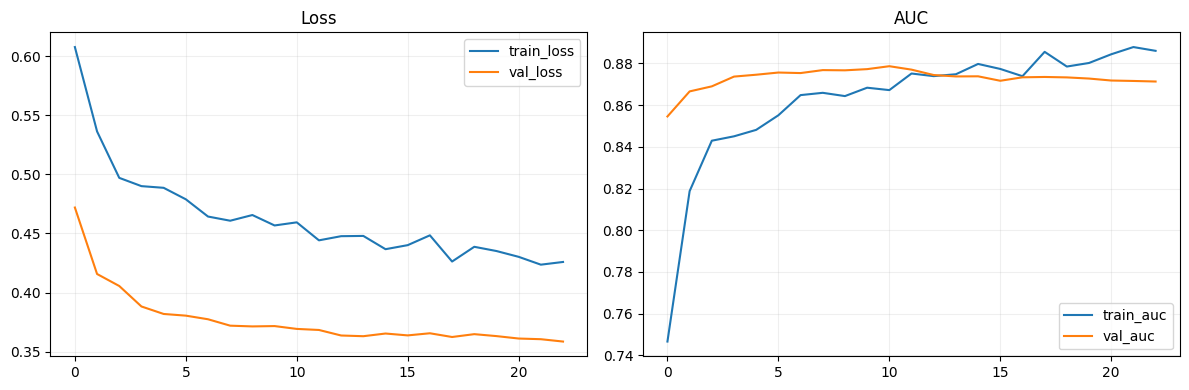

In [26]:
hist = pd.DataFrame(history.history)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(hist["loss"], label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.title("Loss")
plt.legend()
plt.grid(alpha=0.2)

plt.subplot(1, 2, 2)
plt.plot(hist["auc"], label="train_auc")
plt.plot(hist["val_auc"], label="val_auc")
plt.title("AUC")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [27]:
val_prob = model.predict(X_val_sc, verbose=0).ravel()

thresholds = np.linspace(0.10, 0.90, 81)

rows_thr = []
for thr in thresholds:
    val_pred = (val_prob >= thr).astype(np.int64)
    rows_thr.append({
        "threshold": thr,
        "balanced_acc": balanced_accuracy_score(y_val, val_pred),
        "f1": f1_score(y_val, val_pred, zero_division=0),
        "precision": precision_score(y_val, val_pred, zero_division=0),
        "recall": recall_score(y_val, val_pred, zero_division=0),
    })

thr_df = pd.DataFrame(rows_thr).sort_values(["balanced_acc", "f1"], ascending=False).reset_index(drop=True)
display(thr_df.head(10))

BEST_THRESHOLD = float(thr_df.iloc[0]["threshold"])
print("BEST_THRESHOLD =", BEST_THRESHOLD)

,threshold,balanced_acc,f1,precision,recall
0,0.38,0.810556,0.577778,0.448276,0.8125
1,0.42,0.806160,0.590476,0.476923,0.7750
2,0.39,0.805502,0.573991,0.447552,0.8000
3,0.35,0.805114,0.553719,0.413580,0.8375
4,0.37,0.804575,0.565217,0.433333,0.8125
5,0.40,0.804037,0.577982,0.456522,0.7875
6,0.36,0.803648,0.556962,0.420382,0.8250
7,0.45,0.801764,0.605128,0.513043,0.7375
8,0.41,0.801376,0.579439,0.462687,0.7750
9,0.51,0.800957,0.632768,0.577320,0.7000


BEST_THRESHOLD = 0.38


In [28]:
test_prob = model.predict(X_test_sc, verbose=0).ravel()
test_pred = (test_prob >= BEST_THRESHOLD).astype(np.int64)

print("=== TEST REPORT ===")
print(f"Threshold = {BEST_THRESHOLD:.3f}\n")
print(classification_report(y_test, test_pred, digits=4))

print("Balanced accuracy:", balanced_accuracy_score(y_test, test_pred))
print("F1 score         :", f1_score(y_test, test_pred))
print("Precision        :", precision_score(y_test, test_pred, zero_division=0))
print("Recall           :", recall_score(y_test, test_pred, zero_division=0))
print("ROC-AUC          :", roc_auc_score(y_test, test_prob))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, test_pred))

=== TEST REPORT ===
Threshold = 0.380

              precision    recall  f1-score   support

           0     0.9469    0.7952    0.8644       830
           1     0.4198    0.7688    0.5430       160

    accuracy                         0.7909       990
   macro avg     0.6834    0.7820    0.7037       990
weighted avg     0.8617    0.7909    0.8125       990

Balanced accuracy: 0.7819653614457831
F1 score         : 0.543046357615894
Precision        : 0.4197952218430034
Recall           : 0.76875
ROC-AUC          : 0.849585843373494

Confusion matrix:
[[660 170]
 [ 37 123]]


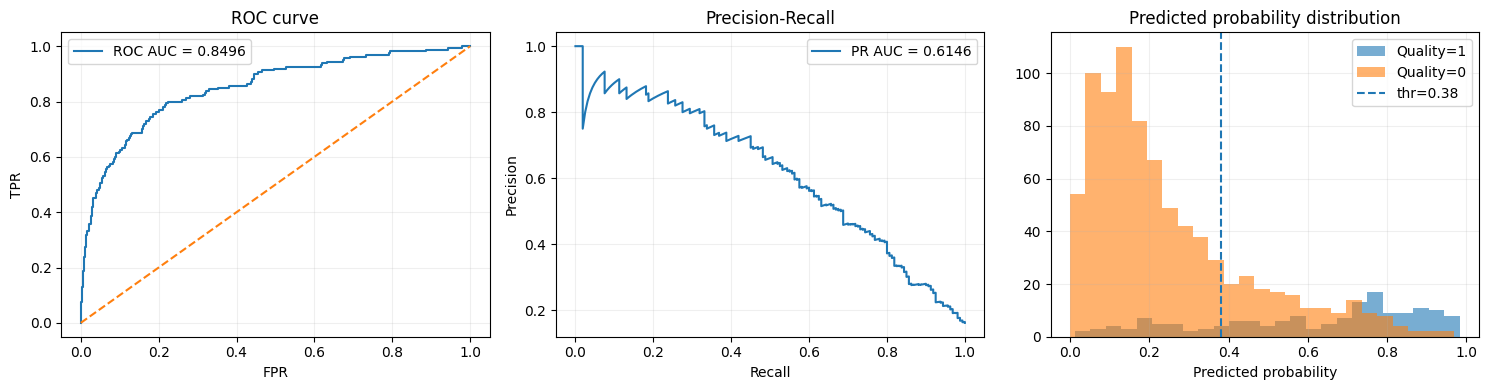

In [29]:
fpr, tpr, _ = roc_curve(y_test, test_prob)
roc_auc = auc(fpr, tpr)

prec, rec, _ = precision_recall_curve(y_test, test_prob)
pr_auc = auc(rec, prec)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC curve")
plt.legend()
plt.grid(alpha=0.2)

plt.subplot(1, 3, 2)
plt.plot(rec, prec, label=f"PR AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall")
plt.legend()
plt.grid(alpha=0.2)

plt.subplot(1, 3, 3)
plt.hist(test_prob[y_test == 1], bins=25, alpha=0.6, label="Quality=1")
plt.hist(test_prob[y_test == 0], bins=25, alpha=0.6, label="Quality=0")
plt.axvline(BEST_THRESHOLD, linestyle="--", label=f"thr={BEST_THRESHOLD:.2f}")
plt.title("Predicted probability distribution")
plt.xlabel("Predicted probability")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [30]:
test_view = test_df[["ID", "subject_id", "Quality"]].copy()
test_view["prob"] = test_prob
test_view["pred"] = test_pred
test_view["correct"] = (test_view["Quality"] == test_view["pred"]).astype(int)

print("=== Mẫu đoán sai ===")
display(test_view[test_view["correct"] == 0].sort_values("prob").head(20))

print("=== Mẫu đoán đúng, confidence cao ===")
display(
    test_view.assign(conf=np.abs(test_view["prob"] - BEST_THRESHOLD))
             .sort_values("conf", ascending=False)
             .head(20)
)

=== Mẫu đoán sai ===


,ID,subject_id,Quality,prob,pred,correct
292,125035,125,1,0.012631,0,0
380,126015,126,1,0.035334,0,0
673,132104,132,1,0.054197,0,0
771,139094,139,1,0.085366,0,0
889,148008,148,1,0.088270,0,0
769,139092,139,1,0.105783,0,0
772,139095,139,1,0.120638,0,0
274,125017,125,1,0.123240,0,0
724,139047,139,1,0.123922,0,0
98,117045,117,1,0.139877,0,0


=== Mẫu đoán đúng, confidence cao ===


,ID,subject_id,Quality,prob,pred,correct,conf
267,125010,125,1,0.982564,1,1,0.602564
357,125100,125,1,0.974683,1,1,0.594683
307,125050,125,1,0.973793,1,1,0.593793
848,145063,145,0,0.968354,1,0,0.588354
310,125053,125,1,0.963874,1,1,0.583874
308,125051,125,1,0.957980,1,1,0.577980
359,125102,125,1,0.948664,1,1,0.568664
303,125046,125,1,0.945827,1,1,0.565827
358,125101,125,1,0.945350,1,1,0.565350
577,132008,132,1,0.937077,1,1,0.557077


In [31]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

X_all = feature_df[feature_cols].astype(np.float32).values
y_all = feature_df["Quality"].values.astype(np.int64)
groups_all = feature_df["subject_id"].values

X_all = np.nan_to_num(X_all, nan=0.0, posinf=0.0, neginf=0.0)

gkf = GroupKFold(n_splits=5)
cv_rows = []

for fold, (tr_idx, te_idx) in enumerate(gkf.split(X_all, y_all, groups=groups_all), start=1):
    X_tr = X_all[tr_idx]
    y_tr = y_all[tr_idx]
    X_te = X_all[te_idx]
    y_te = y_all[te_idx]

    cw = compute_class_weight(class_weight="balanced", classes=np.unique(y_tr), y=y_tr)
    cw_dict = {int(c): float(w) for c, w in zip(np.unique(y_tr), cw)}
    sample_weight = np.array([cw_dict[int(v)] for v in y_tr], dtype=np.float32)

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            solver="adam",
            batch_size=32,
            max_iter=250,
            random_state=SEED + fold,
            early_stopping=True,
            validation_fraction=0.15
        ))
    ])

    clf.fit(X_tr, y_tr, mlp__sample_weight=sample_weight)

    prob = clf.predict_proba(X_te)[:, 1]
    pred = (prob >= 0.5).astype(np.int64)

    cv_rows.append({
        "fold": fold,
        "test_pos_rate": float(np.mean(y_te)),
        "balanced_acc": float(balanced_accuracy_score(y_te, pred)),
        "f1": float(f1_score(y_te, pred, zero_division=0)),
        "precision": float(precision_score(y_te, pred, zero_division=0)),
        "recall": float(recall_score(y_te, pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_te, prob)),
    })

cv_df = pd.DataFrame(cv_rows)
display(cv_df)

print("=== Mean CV metrics ===")
display(cv_df.mean(numeric_only=True))

,fold,test_pos_rate,balanced_acc,f1,precision,recall,roc_auc
0,1,0.219298,0.845618,0.718204,0.637168,0.822857,0.890007
1,2,0.097744,0.721795,0.410959,0.319149,0.576923,0.791845
2,3,0.201571,0.762785,0.573604,0.470833,0.733766,0.812487
3,4,0.344241,0.818117,0.756661,0.710000,0.809886,0.879875
4,5,0.209424,0.736796,0.565097,0.507463,0.637500,0.805629


=== Mean CV metrics ===


fold             3.000000
test_pos_rate    0.214456
balanced_acc     0.777022
f1               0.604905
precision        0.528923
recall           0.716186
roc_auc          0.835969
dtype: float64

In [32]:
EXPORT_DIR = Path("./but_ppg_feature_quality_artifacts")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# 1) lưu scaler
joblib.dump(scaler, EXPORT_DIR / "scaler.joblib")

# 2) lưu feature list
with open(EXPORT_DIR / "feature_columns.json", "w", encoding="utf-8") as f:
    json.dump(feature_cols, f, indent=2, ensure_ascii=False)

# 3) lưu threshold và config
config = {
    "best_threshold": BEST_THRESHOLD,
    "seed": SEED,
    "n_features": len(feature_cols),
    "feature_cols": feature_cols,
}
with open(EXPORT_DIR / "model_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

# 4) lưu keras model
model.save(EXPORT_DIR / "keras_model.keras")

print("Saved to:", EXPORT_DIR.resolve())

Saved to: C:\ml\kaggle-ml-basics\but_ppg_feature_quality_artifacts


In [33]:
keras_model_path = EXPORT_DIR / "keras_model.keras"
loaded_model = keras.models.load_model(keras_model_path)

converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)
tflite_model = converter.convert()

tflite_path = EXPORT_DIR / "model_float32.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print("Saved:", tflite_path)
print("Size (bytes):", os.path.getsize(tflite_path))

INFO:tensorflow:Assets written to: C:\Users\nguye\AppData\Local\Temp\tmpyodqglor\assets


INFO:tensorflow:Assets written to: C:\Users\nguye\AppData\Local\Temp\tmpyodqglor\assets


Saved artifact at 'C:\Users\nguye\AppData\Local\Temp\tmpyodqglor'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 54), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2339288194640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2339288200592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2339288202704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2339288197904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2339288203088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2339288191184: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved: but_ppg_feature_quality_artifacts\model_float32.tflite
Size (bytes): 11280


In [34]:
def representative_dataset():
    n = min(200, len(X_train_sc))
    idx = np.random.choice(len(X_train_sc), size=n, replace=False)
    for i in idx:
        yield [X_train_sc[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset

# full integer quantization
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32

tflite_int8 = converter.convert()

tflite_int8_path = EXPORT_DIR / "model_int8.tflite"
with open(tflite_int8_path, "wb") as f:
    f.write(tflite_int8)

print("Saved:", tflite_int8_path)
print("Size (bytes):", os.path.getsize(tflite_int8_path))

INFO:tensorflow:Assets written to: C:\Users\nguye\AppData\Local\Temp\tmpey8fat57\assets


INFO:tensorflow:Assets written to: C:\Users\nguye\AppData\Local\Temp\tmpey8fat57\assets


Saved artifact at 'C:\Users\nguye\AppData\Local\Temp\tmpey8fat57'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 54), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2339288194640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2339288200592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2339288202704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2339288197904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2339288203088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2339288191184: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved: but_ppg_feature_quality_artifacts\model_int8.tflite
Size (bytes): 6336


In [35]:
interpreter = tf.lite.Interpreter(model_path=str(tflite_int8_path))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details:", input_details)
print("Output details:", output_details)

x0 = X_test_sc[:5].astype(np.float32)
preds = []

for i in range(len(x0)):
    interpreter.set_tensor(input_details[0]["index"], x0[i:i+1])
    interpreter.invoke()
    y0 = interpreter.get_tensor(output_details[0]["index"])
    preds.append(float(y0[0][0]))

print("TFLite sample outputs:", preds)

Input details: [{'name': 'serving_default_input_layer:0', 'index': 0, 'shape': array([ 1, 54], dtype=int32), 'shape_signature': array([-1, 54], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 12, 'shape': array([1, 1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
TFLite sample outputs: [0.046875, 0.08984375, 0.328125, 0.60546875, 0.0703125]


In [36]:
def extract_feature_vector_from_signal(sig, fs, feature_cols, scaler):
    feats = extract_ppg_features(sig, fs)
    row = pd.DataFrame([feats], columns=feature_cols)
    row = row.fillna(0.0)
    x = row.values.astype(np.float32)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    x_sc = scaler.transform(x).astype(np.float32)
    return x_sc


def predict_quality_prob_from_signal(sig, fs, model, feature_cols, scaler):
    x_sc = extract_feature_vector_from_signal(sig, fs, feature_cols, scaler)
    prob = float(model.predict(x_sc, verbose=0).ravel()[0])
    return prob


# test trên 1 sample
sample_id = test_df.iloc[0]["ID"]
sig, fs = load_record_ppg(sample_id)
prob = predict_quality_prob_from_signal(sig, fs, model, feature_cols, scaler)
print("sample_id:", sample_id)
print("pred prob:", prob)
print("pred label:", int(prob >= BEST_THRESHOLD))
print("true label:", int(test_df.iloc[0]["Quality"]))

sample_id: 113001
pred prob: 0.04839114099740982
pred label: 0
true label: 0


In [37]:
print("=== Tóm tắt ===")
print(f"- Số feature: {len(feature_cols)}")
print(f"- Threshold tối ưu theo validation: {BEST_THRESHOLD:.3f}")
print("- Artifact đã lưu trong thư mục:", EXPORT_DIR.resolve())
print("- Bước tiếp theo: dùng đúng hàm extract_ppg_features() này cho dữ liệu MAX30102 thật.")

=== Tóm tắt ===
- Số feature: 54
- Threshold tối ưu theo validation: 0.380
- Artifact đã lưu trong thư mục: C:\ml\kaggle-ml-basics\but_ppg_feature_quality_artifacts
- Bước tiếp theo: dùng đúng hàm extract_ppg_features() này cho dữ liệu MAX30102 thật.


,feature,rf_importance
0,ac_best,0.076848
1,q10,0.075416
2,spectral_entropy,0.048856
3,psd_hr_ratio,0.040293
4,peak_prom_std,0.033634
5,psd_low_power,0.032664
6,q75,0.028762
7,raw_std,0.027197
8,raw_ptp,0.025155
9,ibi_diff_rmssd,0.023732


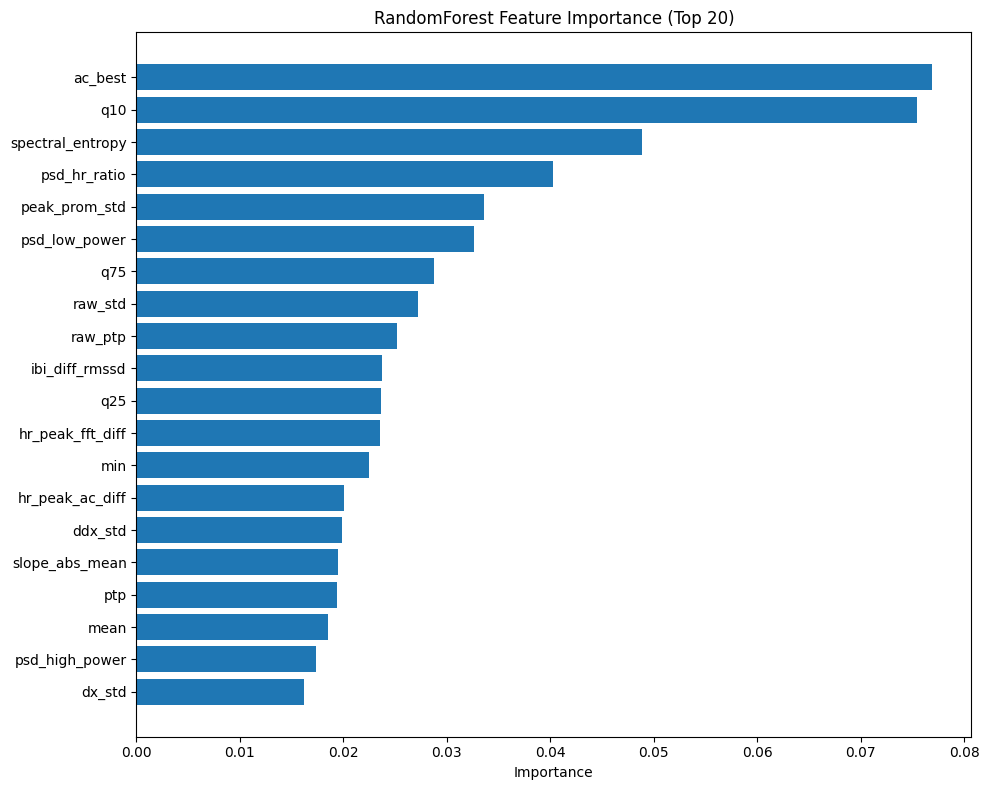

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "rf_importance": rf.feature_importances_
}).sort_values("rf_importance", ascending=False).reset_index(drop=True)

display(rf_importance_df.head(25))

plt.figure(figsize=(10, 8))
topn = 20
plt.barh(
    rf_importance_df["feature"].head(topn)[::-1],
    rf_importance_df["rf_importance"].head(topn)[::-1]
)
plt.title("RandomForest Feature Importance (Top 20)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

,feature,perm_mean,perm_std
0,ac_best,0.014415,0.011357
1,raw_ptp,0.010061,0.010029
2,dom_freq_hr_band,0.006975,0.006767
3,raw_std,0.006059,0.008248
4,dom_bpm_hr_band,0.004834,0.004841
5,energy,0.003989,0.003050
6,std,0.003364,0.003627
7,psd_hr_power,0.002766,0.003173
8,dom_power_hr_band,0.002493,0.004184
9,ac_lag1,0.002280,0.002769


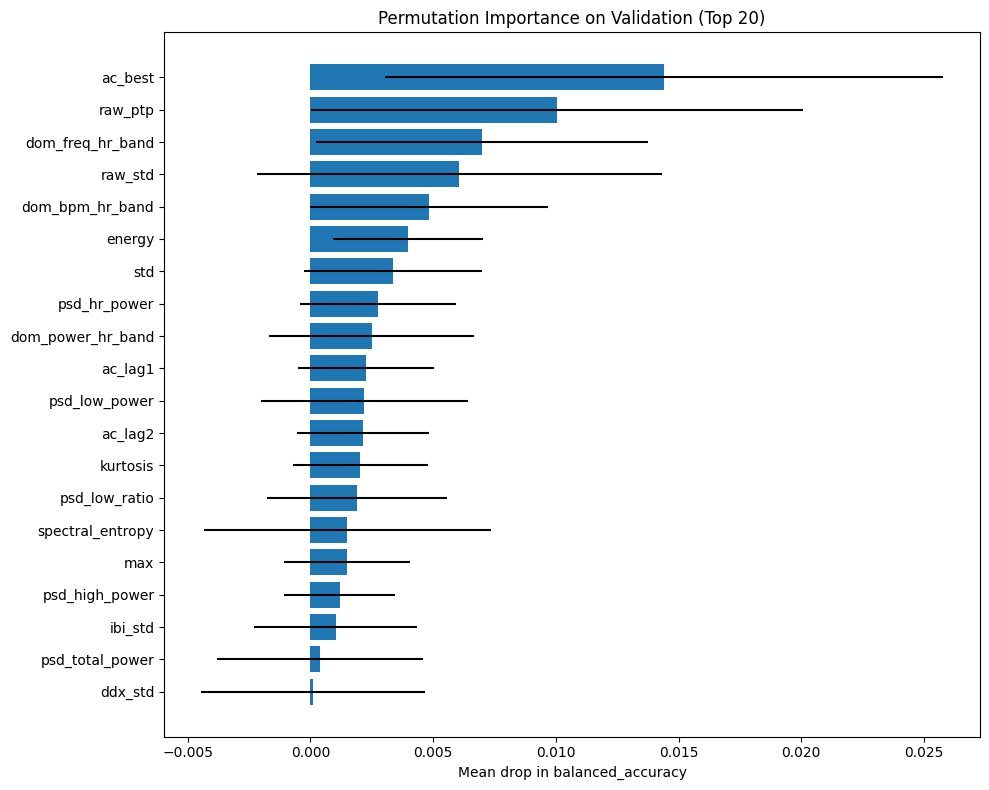

In [39]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_val,
    y_val,
    n_repeats=20,
    random_state=SEED,
    scoring="balanced_accuracy",
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "perm_mean": perm.importances_mean,
    "perm_std": perm.importances_std
}).sort_values("perm_mean", ascending=False).reset_index(drop=True)

display(perm_importance_df.head(25))

plt.figure(figsize=(10, 8))
topn = 20
plt.barh(
    perm_importance_df["feature"].head(topn)[::-1],
    perm_importance_df["perm_mean"].head(topn)[::-1],
    xerr=perm_importance_df["perm_std"].head(topn)[::-1]
)
plt.title("Permutation Importance on Validation (Top 20)")
plt.xlabel("Mean drop in balanced_accuracy")
plt.tight_layout()
plt.show()

In [40]:
rank_df = rf_importance_df.merge(perm_importance_df, on="feature", how="outer")

rank_df["rf_rank"] = rank_df["rf_importance"].rank(ascending=False, method="min")
rank_df["perm_rank"] = rank_df["perm_mean"].rank(ascending=False, method="min")

rank_df["combined_rank_score"] = rank_df["rf_rank"] + rank_df["perm_rank"]
rank_df = rank_df.sort_values("combined_rank_score", ascending=True).reset_index(drop=True)

display(rank_df.head(30))

,feature,rf_importance,perm_mean,perm_std,rf_rank,perm_rank,combined_rank_score
0,ac_best,0.076848,0.014415,0.011357,1.0,1.0,2.0
1,raw_ptp,0.025155,0.010061,0.010029,9.0,2.0,11.0
2,raw_std,0.027197,0.006059,0.008248,8.0,4.0,12.0
3,psd_low_power,0.032664,0.002201,0.004208,6.0,11.0,17.0
4,spectral_entropy,0.048856,0.001510,0.005830,3.0,15.0,18.0
5,dom_freq_hr_band,0.015590,0.006975,0.006767,23.0,3.0,26.0
6,dom_bpm_hr_band,0.015172,0.004834,0.004841,25.0,5.0,30.0
7,psd_hr_ratio,0.040293,-0.000280,0.002725,4.0,27.0,31.0
8,ibi_diff_rmssd,0.023732,-0.000025,0.003332,10.0,24.0,34.0
9,ddx_std,0.019857,0.000120,0.004565,15.0,20.0,35.0


In [41]:
def train_and_eval_subset(selected_features, threshold_mode="tune_on_val"):
    print("=" * 80)
    print("Số feature:", len(selected_features))
    print(selected_features)

    Xtr = train_df[selected_features].astype(np.float32).values
    Xva = val_df[selected_features].astype(np.float32).values
    Xte = test_df[selected_features].astype(np.float32).values

    Xtr = np.nan_to_num(Xtr, nan=0.0, posinf=0.0, neginf=0.0)
    Xva = np.nan_to_num(Xva, nan=0.0, posinf=0.0, neginf=0.0)
    Xte = np.nan_to_num(Xte, nan=0.0, posinf=0.0, neginf=0.0)

    scaler_sub = StandardScaler()
    Xtr_sc = scaler_sub.fit_transform(Xtr).astype(np.float32)
    Xva_sc = scaler_sub.transform(Xva).astype(np.float32)
    Xte_sc = scaler_sub.transform(Xte).astype(np.float32)

    model_sub = build_tiny_mlp(Xtr_sc.shape[1])

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=12,
            restore_best_weights=True,
            verbose=0
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.5,
            patience=5,
            min_lr=1e-5,
            verbose=0
        )
    ]

    model_sub.fit(
        Xtr_sc,
        y_train,
        validation_data=(Xva_sc, y_val),
        epochs=120,
        batch_size=32,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=0
    )

    val_prob = model_sub.predict(Xva_sc, verbose=0).ravel()

    thresholds = np.linspace(0.10, 0.90, 81)
    best_thr = 0.5
    best_bacc = -1

    for thr in thresholds:
        val_pred = (val_prob >= thr).astype(np.int64)
        bacc = balanced_accuracy_score(y_val, val_pred)
        if bacc > best_bacc:
            best_bacc = bacc
            best_thr = thr

    test_prob = model_sub.predict(Xte_sc, verbose=0).ravel()
    test_pred = (test_prob >= best_thr).astype(np.int64)

    result = {
        "n_features": len(selected_features),
        "threshold": float(best_thr),
        "balanced_acc": float(balanced_accuracy_score(y_test, test_pred)),
        "f1": float(f1_score(y_test, test_pred)),
        "precision": float(precision_score(y_test, test_pred, zero_division=0)),
        "recall": float(recall_score(y_test, test_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_test, test_prob)),
    }

    return result, model_sub, scaler_sub

In [42]:
top12 = rank_df["feature"].head(12).tolist()
top16 = rank_df["feature"].head(16).tolist()
top20 = rank_df["feature"].head(20).tolist()

results = []

for feat_set in [top12, top16, top20]:
    res, _, _ = train_and_eval_subset(feat_set)
    res["features"] = feat_set
    results.append(res)

subset_compare_df = pd.DataFrame(results).sort_values(
    ["balanced_acc", "roc_auc", "f1"], ascending=False
).reset_index(drop=True)

display(subset_compare_df[["n_features", "threshold", "balanced_acc", "f1", "precision", "recall", "roc_auc"]])

Số feature: 12
['ac_best', 'raw_ptp', 'raw_std', 'psd_low_power', 'spectral_entropy', 'dom_freq_hr_band', 'dom_bpm_hr_band', 'psd_hr_ratio', 'ibi_diff_rmssd', 'ddx_std', 'psd_low_ratio', 'psd_high_power']
Số feature: 16
['ac_best', 'raw_ptp', 'raw_std', 'psd_low_power', 'spectral_entropy', 'dom_freq_hr_band', 'dom_bpm_hr_band', 'psd_hr_ratio', 'ibi_diff_rmssd', 'ddx_std', 'psd_low_ratio', 'psd_high_power', 'kurtosis', 'hr_peak_fft_diff', 'std', 'energy']
Số feature: 20
['ac_best', 'raw_ptp', 'raw_std', 'psd_low_power', 'spectral_entropy', 'dom_freq_hr_band', 'dom_bpm_hr_band', 'psd_hr_ratio', 'ibi_diff_rmssd', 'ddx_std', 'psd_low_ratio', 'psd_high_power', 'kurtosis', 'hr_peak_fft_diff', 'std', 'energy', 'ibi_std', 'dom_power_hr_band', 'q25', 'min']


,n_features,threshold,balanced_acc,f1,precision,recall,roc_auc
0,12,0.44,0.771950,0.569191,0.488789,0.68125,0.834661
1,16,0.44,0.767620,0.562500,0.482143,0.67500,0.834526
2,20,0.42,0.755045,0.515837,0.404255,0.71250,0.843931


In [43]:
FINAL_FEATURES = rank_df["feature"].head(16).tolist()
print("FINAL_FEATURES =", FINAL_FEATURES)

FINAL_FEATURES = ['ac_best', 'raw_ptp', 'raw_std', 'psd_low_power', 'spectral_entropy', 'dom_freq_hr_band', 'dom_bpm_hr_band', 'psd_hr_ratio', 'ibi_diff_rmssd', 'ddx_std', 'psd_low_ratio', 'psd_high_power', 'kurtosis', 'hr_peak_fft_diff', 'std', 'energy']


In [72]:
FINAL_FEATURES = [
    "ac_best",
    "raw_ptp",
    "raw_std",
    "ddx_std",
    "std",
    "dom_bpm_hr_band",
    "psd_low_ratio",
    "spectral_entropy",
    "psd_hr_ratio",
    "hr_peak_fft_diff",
]
print("FINAL_FEATURES =", FINAL_FEATURES)

FINAL_FEATURES = ['ac_best', 'raw_ptp', 'raw_std', 'ddx_std', 'std', 'dom_bpm_hr_band', 'psd_low_ratio', 'spectral_entropy', 'psd_hr_ratio', 'hr_peak_fft_diff']


In [73]:
X_train_f = train_df[FINAL_FEATURES].astype(np.float32).values
X_val_f   = val_df[FINAL_FEATURES].astype(np.float32).values
X_test_f  = test_df[FINAL_FEATURES].astype(np.float32).values

X_train_f = np.nan_to_num(X_train_f, nan=0.0, posinf=0.0, neginf=0.0)
X_val_f   = np.nan_to_num(X_val_f, nan=0.0, posinf=0.0, neginf=0.0)
X_test_f  = np.nan_to_num(X_test_f, nan=0.0, posinf=0.0, neginf=0.0)

scaler_final = StandardScaler()
X_train_f_sc = scaler_final.fit_transform(X_train_f).astype(np.float32)
X_val_f_sc   = scaler_final.transform(X_val_f).astype(np.float32)
X_test_f_sc  = scaler_final.transform(X_test_f).astype(np.float32)

model_final = build_tiny_mlp(X_train_f_sc.shape[1])

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

history_final = model_final.fit(
    X_train_f_sc,
    y_train,
    validation_data=(X_val_f_sc, y_val),
    epochs=120,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/120
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - acc: 0.5487 - auc: 0.6901 - loss: 0.6482 - precision: 0.3178 - recall: 0.7288 - val_acc: 0.8032 - val_auc: 0.8359 - val_loss: 0.5677 - val_precision: 0.4328 - val_recall: 0.7250 - learning_rate: 0.0010
Epoch 2/120
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7529 - auc: 0.8200 - loss: 0.5396 - precision: 0.4983 - recall: 0.7559 - val_acc: 0.8333 - val_auc: 0.8481 - val_loss: 0.4393 - val_precision: 0.4865 - val_recall: 0.6750 - learning_rate: 0.0010
Epoch 3/120
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7896 - auc: 0.8314 - loss: 0.5072 - precision: 0.5533 - recall: 0.7475 - val_acc: 0.8434 - val_auc: 0.8461 - val_loss: 0.4091 - val_precision: 0.5100 - val_recall: 0.6375 - learning_rate: 0.0010
Epoch 4/120
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7967 - auc: 0.8386 - loss: 0.4987 - precision: 0.5664 - recall: 0.7373 - val_acc: 0.8474 - val_auc: 0.8436 - val_loss: 0.3998 - val_precision: 0.5204 - val_recall: 0.6375 - le

In [74]:
val_prob_f = model_final.predict(X_val_f_sc, verbose=0).ravel()

thresholds = np.linspace(0.10, 0.90, 81)

rows_thr_f = []
for thr in thresholds:
    val_pred_f = (val_prob_f >= thr).astype(np.int64)
    rows_thr_f.append({
        "threshold": thr,
        "balanced_acc": balanced_accuracy_score(y_val, val_pred_f),
        "f1": f1_score(y_val, val_pred_f, zero_division=0),
        "precision": precision_score(y_val, val_pred_f, zero_division=0),
        "recall": recall_score(y_val, val_pred_f, zero_division=0),
    })

thr_final_df = pd.DataFrame(rows_thr_f).sort_values(
    ["balanced_acc", "f1"], ascending=False
).reset_index(drop=True)

display(thr_final_df.head(10))

BEST_THRESHOLD_FINAL = float(thr_final_df.iloc[0]["threshold"])
print("BEST_THRESHOLD_FINAL =", BEST_THRESHOLD_FINAL)

,threshold,balanced_acc,f1,precision,recall
0,0.42,0.795006,0.546218,0.411392,0.8125
1,0.44,0.792075,0.552632,0.425676,0.7875
2,0.43,0.789683,0.547826,0.420000,0.7875
3,0.40,0.789294,0.530120,0.390533,0.8250
4,0.41,0.789025,0.534979,0.398773,0.8125
5,0.39,0.778529,0.511628,0.370787,0.8250
6,0.45,0.774252,0.541284,0.427536,0.7375
7,0.47,0.769856,0.551724,0.455285,0.7000
8,0.50,0.769318,0.565445,0.486486,0.6750
9,0.38,0.768959,0.496241,0.354839,0.8250


BEST_THRESHOLD_FINAL = 0.42000000000000004


In [75]:
test_prob_f = model_final.predict(X_test_f_sc, verbose=0).ravel()
test_pred_f = (test_prob_f >= BEST_THRESHOLD_FINAL).astype(np.int64)

print("=== FINAL TEST REPORT ===")
print(f"Threshold = {BEST_THRESHOLD_FINAL:.3f}\n")
print(classification_report(y_test, test_pred_f, digits=4))

print("Balanced accuracy:", balanced_accuracy_score(y_test, test_pred_f))
print("F1 score         :", f1_score(y_test, test_pred_f))
print("Precision        :", precision_score(y_test, test_pred_f, zero_division=0))
print("Recall           :", recall_score(y_test, test_pred_f, zero_division=0))
print("ROC-AUC          :", roc_auc_score(y_test, test_prob_f))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, test_pred_f))

=== FINAL TEST REPORT ===
Threshold = 0.420

              precision    recall  f1-score   support

           0     0.9374    0.7759    0.8490       830
           1     0.3861    0.7312    0.5054       160

    accuracy                         0.7687       990
   macro avg     0.6618    0.7536    0.6772       990
weighted avg     0.8483    0.7687    0.7935       990

Balanced accuracy: 0.7535768072289156
F1 score         : 0.5053995680345572
Precision        : 0.38613861386138615
Recall           : 0.73125
ROC-AUC          : 0.8251430722891567

Confusion matrix:
[[644 186]
 [ 43 117]]


In [62]:
X_all_f = feature_df[FINAL_FEATURES].astype(np.float32).values
y_all_f = feature_df["Quality"].values.astype(np.int64)
groups_all_f = feature_df["subject_id"].values

X_all_f = np.nan_to_num(X_all_f, nan=0.0, posinf=0.0, neginf=0.0)

gkf = GroupKFold(n_splits=5)
cv_rows_final = []

for fold, (tr_idx, te_idx) in enumerate(gkf.split(X_all_f, y_all_f, groups=groups_all_f), start=1):
    X_tr = X_all_f[tr_idx]
    y_tr = y_all_f[tr_idx]
    X_te = X_all_f[te_idx]
    y_te = y_all_f[te_idx]

    scaler_cv = StandardScaler()
    X_tr_sc = scaler_cv.fit_transform(X_tr)
    X_te_sc = scaler_cv.transform(X_te)

    cw = compute_class_weight(class_weight="balanced", classes=np.unique(y_tr), y=y_tr)
    cw_dict = {int(c): float(w) for c, w in zip(np.unique(y_tr), cw)}

    model_cv = build_tiny_mlp(X_tr_sc.shape[1])

    model_cv.fit(
        X_tr_sc, y_tr,
        validation_split=0.15,
        epochs=80,
        batch_size=32,
        class_weight=cw_dict,
        verbose=0
    )

    prob = model_cv.predict(X_te_sc, verbose=0).ravel()
    pred = (prob >= 0.5).astype(np.int64)

    cv_rows_final.append({
        "fold": fold,
        "balanced_acc": float(balanced_accuracy_score(y_te, pred)),
        "f1": float(f1_score(y_te, pred, zero_division=0)),
        "precision": float(precision_score(y_te, pred, zero_division=0)),
        "recall": float(recall_score(y_te, pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_te, prob)),
    })

cv_final_df = pd.DataFrame(cv_rows_final)
display(cv_final_df)
print("=== Mean CV metrics ===")
display(cv_final_df.mean(numeric_only=True))

,fold,balanced_acc,f1,precision,recall,roc_auc
0,1,0.782055,0.637532,0.579439,0.708571,0.854529
1,2,0.679808,0.332046,0.237569,0.551282,0.752956
2,3,0.791282,0.611825,0.506383,0.772727,0.848946
3,4,0.807898,0.745455,0.714286,0.779468,0.881932
4,5,0.707305,0.535385,0.527273,0.543750,0.785886


=== Mean CV metrics ===


fold            3.000000
balanced_acc    0.753669
f1              0.572449
precision       0.512990
recall          0.671160
roc_auc         0.824850
dtype: float64

In [76]:
CANDIDATE_FEATURE_SETS = {
    "A_easy_8": [
        "ac_best",
        "raw_ptp",
        "raw_std",
        "ddx_std",
        "std",
        "dom_bpm_hr_band",
        "psd_low_ratio",
        "spectral_entropy",
    ],
    "B_balanced_10": [
        "ac_best",
        "raw_ptp",
        "raw_std",
        "ddx_std",
        "std",
        "dom_bpm_hr_band",
        "psd_low_ratio",
        "spectral_entropy",
        "psd_hr_ratio",
        "hr_peak_fft_diff",
    ],
    "C_balanced_11": [
        "ac_best",
        "raw_ptp",
        "raw_std",
        "ddx_std",
        "std",
        "dom_bpm_hr_band",
        "psd_low_ratio",
        "spectral_entropy",
        "psd_hr_ratio",
        "hr_peak_fft_diff",
        "ibi_diff_rmssd",
    ],
}

candidate_results = []

for name, feat_set in CANDIDATE_FEATURE_SETS.items():
    res, _, _ = train_and_eval_subset(feat_set)
    res["name"] = name
    res["features"] = feat_set
    candidate_results.append(res)

candidate_compare_df = pd.DataFrame(candidate_results).sort_values(
    ["balanced_acc", "roc_auc", "f1"], ascending=False
).reset_index(drop=True)

display(candidate_compare_df[[
    "name", "n_features", "threshold",
    "balanced_acc", "f1", "precision", "recall", "roc_auc"
]])

Số feature: 8
['ac_best', 'raw_ptp', 'raw_std', 'ddx_std', 'std', 'dom_bpm_hr_band', 'psd_low_ratio', 'spectral_entropy']
Số feature: 10
['ac_best', 'raw_ptp', 'raw_std', 'ddx_std', 'std', 'dom_bpm_hr_band', 'psd_low_ratio', 'spectral_entropy', 'psd_hr_ratio', 'hr_peak_fft_diff']
Số feature: 11
['ac_best', 'raw_ptp', 'raw_std', 'ddx_std', 'std', 'dom_bpm_hr_band', 'psd_low_ratio', 'spectral_entropy', 'psd_hr_ratio', 'hr_peak_fft_diff', 'ibi_diff_rmssd']


,name,n_features,threshold,balanced_acc,f1,precision,recall,roc_auc
0,C_balanced_11,11,0.38,0.764797,0.532407,0.422794,0.71875,0.839277
1,A_easy_8,8,0.34,0.751657,0.504348,0.386667,0.72500,0.820971
2,B_balanced_10,10,0.40,0.743750,0.504587,0.398551,0.68750,0.813652
